# ∂-FNO Theory Validation: Burgers Equation (Near-Shock, ν=0.001)

## Supplementary Material for Figure 3

> **Note:** This notebook is provided for illustration purposes only.  
> Full code and reproducible experiments will be available on GitHub upon acceptance.
>
> Results may vary with hardware configurations.  
> **Tip:** Lower batch sizes generally yield better metrics but require longer training time.

---

### Experimental Setup

| Setting | Value |
|---------|-------|
| Model | FNO (width 64, 4 layers) |
| Dataset | Burgers (ν=0.001, near-shock regime) |
| Learnable | Single β (initialized at 1.5) |
| Seeds | 3 |
| Default | n=1800, σ=0.01, k=16 |

### Experiments

| Panel | Sweep Variable | Values | Fixed Parameters |
|-------|---------------|--------|------------------|
| **Left** | Noise σ | {0.0, 0.01, 0.02, 0.05, 0.10} | n=1000, k=16 |
| **Center** | Samples n | {125, 250, 500, 1000, 1800} | σ=0.01, k=16 |
| **Right** | Modes k | {16, 32, 64, 128} | n=1000, σ=0.01 |

### Theoretical Predictions (Theorem 5.4)
- σ ↑ ⇒ β* ↓ (more noise → lower optimal order)
- n ↑ ⇒ β* ↑ (more data → higher optimal order)  
- k ↑ ⇒ β* ↓ (more capacity → lower optimal order)

### Note on Near-Shock Regime
The near-shock case (ν=0.001) approaches the regularity boundary where solutions develop steep gradients. The theory provides qualitative guidance even when quantitative assumptions are marginal.

In [ ]:
# @title Cell 1: Imports and Setup
import os
import sys
import json
import time
import glob
import logging
from datetime import datetime
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Tuple, Optional, Any
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════════════════════════════
#                         LOGGING SETUP
# ═══════════════════════════════════════════════════════════════════
def setup_logger(name: str, log_file: str = None, level=logging.INFO):
    """Setup logger with console and optional file output."""
    logger = logging.getLogger(name)
    logger.setLevel(level)
    logger.handlers = []  # Clear existing handlers

    # Console handler
    console = logging.StreamHandler()
    console.setLevel(level)
    fmt = logging.Formatter('%(asctime)s | %(levelname)s | %(message)s', datefmt='%H:%M:%S')
    console.setFormatter(fmt)
    logger.addHandler(console)

    # File handler (optional)
    if log_file:
        os.makedirs(os.path.dirname(log_file), exist_ok=True)
        fh = logging.FileHandler(log_file)
        fh.setLevel(level)
        fh.setFormatter(fmt)
        logger.addHandler(fh)

    return logger

# Create directories before logger
os.makedirs('./results', exist_ok=True)
os.makedirs('./data', exist_ok=True)

# Create main logger
log = setup_logger('DELFNO', log_file='./results/burgers_r1000.log')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
log.info(f"Device: {device}")
if torch.cuda.is_available():
    log.info(f"GPU: {torch.cuda.get_device_name()}")
    log.info(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

17:01:59 | INFO | Device: cuda
INFO:DELFNO:Device: cuda
17:01:59 | INFO | GPU: NVIDIA A100-SXM4-40GB
INFO:DELFNO:GPU: NVIDIA A100-SXM4-40GB
17:01:59 | INFO | Memory: 42.5 GB
INFO:DELFNO:Memory: 42.5 GB


In [ ]:
# @title Cell 2: Configuration
# ═══════════════════════════════════════════════════════════════════
#                    CONFIGURATION - BURGERS R=1000
# ═══════════════════════════════════════════════════════════════════

@dataclass
class Config:
    """Master configuration aligned with neurops.py and DELFNO_BURGERS_SPEC.md"""

    # ==================== DATASET ====================
    dataset: str = 'r1000'       # Burgers R=1000 (sharp/turbulent solutions)
    reynolds: int = 1000

    # ==================== MODEL ARCHITECTURE (neurops.py aligned) ====================
    modes: int = 16              # Fourier modes to keep
    n_hidden: int = 64           # Hidden channel width
    n_layers: int = 4            # Number of FNO blocks (fixed as in original)

    # ==================== DEL-FNO SPECIFIC (from SPEC) ====================
    nb_beta: int = 2             # Number of derivative orders
    K: int = 16                  # Grünwald-Letnikov kernel size
    init_betas: List[float] = field(default_factory=lambda: [1.0, 2.0])
    stencil_only: bool = True    # No h^β normalization
    include_original: bool = True  # Include original signal in augmentation

    # ==================== TRAINING (from SPEC) ====================
    epochs: int = 500           # Training epochs
    batch_size: int = 8          # Batch size
    lr: float = 1e-3             # Learning rate for backbone
    lr_beta: float = 1e-2        # Learning rate for β (10× backbone)
    weight_decay: float = 1e-5   # Weight decay for backbone
    wd_beta: float = 0.0         # No weight decay for β
    grad_clip: float = 1.0       # Gradient clipping

    # ==================== SCHEDULER ====================
    scheduler: str = 'onecycle'  # OneCycleLR (from SPEC)

    # ==================== DATA (R=1000 specific: increased n_train) ====================
    n_train: int = 1000          # Training samples (INCREASED from 1000 as per SPEC)
    n_test: int = 200            # Test samples
    resolution: int = 1024       # Spatial resolution

    # ==================== EXPERIMENT SETTINGS ====================
    seeds: List[int] = field(default_factory=lambda: [42, 108, 888])  # 3 seeds
    models: List[str] = field(default_factory=lambda: ['FNO', 'DEL-FNO'])

    # ==================== EXPERIMENT 1: NOISE ====================
    noise_levels: List[float] = field(default_factory=lambda: [0.0, 0.01, 0.02, 0.05, 0.10])

    # ==================== EXPERIMENT 2: SAMPLE SIZE (extended for R=1000) ====================
    sample_sizes: List[int] = field(default_factory=lambda: [125, 250, 500, 1000, 1800])

    # ==================== EXPERIMENT 3: MODES ====================
    modes_list: List[int] = field(default_factory=lambda: [16, 32, 64, 128])

    # ==================== PATHS ====================
    data_dir: str = './data'
    results_dir: str = './results'

    # ==================== LOGGING ====================
    verbose: bool = True
    log_interval: int = 100      # Log every N epochs
    save_checkpoints: bool = False

    def __post_init__(self):
        os.makedirs(self.results_dir, exist_ok=True)
        os.makedirs(self.data_dir, exist_ok=True)
        if len(self.init_betas) != self.nb_beta:
            self.init_betas = [1.0 * (i + 1) for i in range(self.nb_beta)]

# Create config instance
cfg = Config()

# Log configuration
log.info("="*60)
log.info("CONFIGURATION - BURGERS R=1000 (SHARP/TURBULENT)")
log.info("="*60)
for k, v in asdict(cfg).items():
    log.info(f"  {k}: {v}")
log.info("="*60)

17:01:59 | INFO | ============================================================
INFO:DELFNO:============================================================
17:01:59 | INFO | CONFIGURATION - BURGERS R=1000 (SHARP/TURBULENT)
INFO:DELFNO:CONFIGURATION - BURGERS R=1000 (SHARP/TURBULENT)
17:01:59 | INFO | ============================================================
INFO:DELFNO:============================================================
17:01:59 | INFO |   dataset: r1000
INFO:DELFNO:  dataset: r1000
17:01:59 | INFO |   reynolds: 1000
INFO:DELFNO:  reynolds: 1000
17:01:59 | INFO |   modes: 16
INFO:DELFNO:  modes: 16
17:01:59 | INFO |   n_hidden: 64
INFO:DELFNO:  n_hidden: 64
17:01:59 | INFO |   n_layers: 4
INFO:DELFNO:  n_layers: 4
17:01:59 | INFO |   nb_beta: 2
INFO:DELFNO:  nb_beta: 2
17:01:59 | INFO |   K: 16
INFO:DELFNO:  K: 16
17:01:59 | INFO |   init_betas: [1.0, 2.0]
INFO:DELFNO:  init_betas: [1.0, 2.0]
17:01:59 | INFO |   stencil_only: True
INFO:DELFNO:  stencil_only: True
17:01:59 | INF

In [ ]:
# @title Cell 4: Data Loading
# ═══════════════════════════════════════════════════════════════════
#                         DATA LOADING
# ═══════════════════════════════════════════════════════════════════

def load_burgers_data(cfg: Config) -> Dict[str, torch.Tensor]:
    """
    Load Burgers R=1000 data following canonical FNO MatReader logic.

    Key insight from FNO utilities3.py:
    - scipy.io.loadmat (old .mat): NO transpose
    - h5py (HDF5/MATLAB v7.3): REVERSE all axes (Fortran order)
    """
    data_dir = cfg.data_dir
    reynolds = cfg.reynolds

    GDRIVE_IDS = {
        10: '1vFQHJetdoeU5w4x-cZBoHYvP-MWVtIK9',
        1000: '1G5sQPT4d5gT9dLP7pKBS8sfgKmSM1bVY',
    }
    MIN_SIZES = {10: 50_000_000, 1000: 100_000_000}

    # Find file (R=1000 patterns)
    patterns = [f'{data_dir}/burgers_v1000*.mat', f'{data_dir}/burgers_r1000*.mat',
                f'{data_dir}/Burgers*1000*.mat', f'{data_dir}/burgers_r1000.mat']

    filepath = None
    for p in patterns:
        if '*' in p:
            for f in glob.glob(p):
                if os.path.getsize(f) >= MIN_SIZES.get(reynolds, 1e7):
                    filepath = f
                    break
        elif os.path.exists(p) and os.path.getsize(p) >= MIN_SIZES.get(reynolds, 1e7):
            filepath = p
        if filepath:
            break

    if not filepath:
        import gdown
        filepath = f'{data_dir}/burgers_r{reynolds}.mat'
        log.info(f"Downloading Burgers R={reynolds}...")
        gdown.download(f'https://drive.google.com/uc?id={GDRIVE_IDS[reynolds]}', filepath, quiet=False)

    log.info(f"Loading: {filepath} ({os.path.getsize(filepath)/1e6:.1f}MB)")

    a, u = None, None

    # Try scipy first (older .mat format)
    try:
        import scipy.io
        mat = scipy.io.loadmat(filepath)
        keys = [k for k in mat.keys() if not k.startswith('_')]
        log.info(f"  scipy keys: {keys}")

        if 'a' in mat:
            a, u = mat['a'].astype(np.float32), mat['u'].astype(np.float32)
        elif 'input' in mat:
            a, u = mat['input'].astype(np.float32), mat['output'].astype(np.float32)
        else:
            raise KeyError(f"Unknown keys: {keys}")

    except Exception as e:
        log.info(f"  scipy failed: {e}, trying h5py...")
        import h5py
        with h5py.File(filepath, 'r') as f:
            keys = list(f.keys())
            log.info(f"  h5py keys: {keys}")

            if 'input' in keys:
                a = np.array(f['input']).astype(np.float32)
                u = np.array(f['output']).astype(np.float32)
            elif 'a' in keys:
                a = np.array(f['a']).astype(np.float32)
                u = np.array(f['u']).astype(np.float32)
            else:
                raise KeyError(f"Unknown keys: {keys}")

            # h5py: REVERSE all axes (canonical FNO approach)
            a = np.transpose(a, axes=range(len(a.shape)-1, -1, -1))
            u = np.transpose(u, axes=range(len(u.shape)-1, -1, -1))

    # Handle 3D output (N, T, X) -> take final timestep
    if u.ndim == 3:
        log.info(f"  3D output {u.shape}, taking last timestep")
        if u.shape[1] < u.shape[2]:
            u = u[:, -1, :]
        else:
            u = u[:, :, -1]

    log.info(f"  Shapes after loading: a={a.shape}, u={u.shape}")

    # Subsample to target resolution
    N_grid = a.shape[-1]
    if cfg.resolution < N_grid:
        sub = N_grid // cfg.resolution
        a, u = a[:, ::sub][:, :cfg.resolution], u[:, ::sub][:, :cfg.resolution]

    a, u = torch.from_numpy(a), torch.from_numpy(u)
    log.info(f"  Final shapes: a={a.shape}, u={u.shape}")
    log.info(f"  Total samples available: {a.shape[0]}")

    return {'a': a, 'u': u}


def prepare_data_splits(data: Dict, cfg: Config,
                        n_train: int = None, noise_level: float = 0.0,
                        seed: int = 0) -> Dict[str, torch.Tensor]:
    """
    Prepare train/test splits with optional noise and subsampling.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    a, u = data['a'].clone(), data['u'].clone()

    if n_train is None:
        n_train = cfg.n_train
    n_test = cfg.n_test

    n_total = a.shape[0]
    if n_train + n_test > n_total:
        n_train = min(n_train, n_total - n_test)
        log.warning(f"Reduced n_train to {n_train} due to data size constraints")

    a_train, u_train = a[:n_train].clone(), u[:n_train].clone()
    a_test, u_test = a[n_total - n_test:].clone(), u[n_total - n_test:].clone()

    # Add noise to training inputs only (relative to std)
    if noise_level > 0:
        noise_std = noise_level * a_train.std()
        noise = torch.randn_like(a_train) * noise_std
        a_train = a_train + noise
        log.debug(f"  Added noise: level={noise_level}, std={noise_std:.6f}")

    return {
        'a_train': a_train.to(device),
        'u_train': u_train.to(device),
        'a_test': a_test.to(device),
        'u_test': u_test.to(device),
        'n_train': n_train,
        'noise_level': noise_level,
    }

In [ ]:
# @title Cell 5: Model Definitions - FNO (aligned with neurops.py)
# ═══════════════════════════════════════════════════════════════════
#                    FNO MODEL (neurops.py aligned)
# ═══════════════════════════════════════════════════════════════════

class MLP(nn.Module):
    """Multi-Layer Perceptron with optional residual connections (from neurops.py)"""
    def __init__(self, n_input, n_hidden, n_output, n_layers=1, act='gelu', res=True):
        super().__init__()
        ACTIVATION = {'gelu': nn.GELU, 'relu': nn.ReLU, 'tanh': nn.Tanh, 'silu': nn.SiLU}
        act_fn = ACTIVATION.get(act, nn.GELU)
        self.n_layers = n_layers
        self.res = res
        # Input projection: n_input -> n_hidden with activation
        self.linear_pre = nn.Sequential(nn.Linear(n_input, n_hidden), act_fn())
        # Output projection: n_hidden -> n_output (no activation)
        self.linear_post = nn.Linear(n_hidden, n_output)
        # Hidden layers with activation
        self.linears = nn.ModuleList([
            nn.Sequential(nn.Linear(n_hidden, n_hidden), act_fn()) for _ in range(n_layers)])

    def forward(self, x):
        x = self.linear_pre(x)
        for i in range(self.n_layers):
            x = self.linears[i](x) + x if self.res else self.linears[i](x)
        return self.linear_post(x)


class SpectralConv1d(nn.Module):
    """1D Fourier Spectral Convolution (neurops.py aligned - NO normalization)"""
    def __init__(self, in_ch, out_ch, modes):
        super().__init__()
        self.modes = modes
        scale = 1 / (in_ch * out_ch)
        # IMPORTANT: torch.rand (uniform) not torch.randn (normal) - matches neurops.py
        self.weights = nn.Parameter(scale * torch.rand(in_ch, out_ch, modes, dtype=torch.cfloat))

    def forward(self, x):
        B = x.shape[0]
        # NO norm='ortho' - matches neurops.py
        x_ft = torch.fft.rfft(x)
        out_ft = torch.zeros(B, self.weights.shape[1], x.size(-1)//2+1, device=x.device, dtype=torch.cfloat)
        out_ft[:, :, :self.modes] = torch.einsum("bix,iox->box", x_ft[:, :, :self.modes], self.weights)
        return torch.fft.irfft(out_ft, n=x.size(-1))


class FNO1d(nn.Module):
    """
    Fourier Neural Operator for 1D problems.
    Architecture aligned with neurops.py:
    - MLP preprocess with 2× hidden expansion
    - 4 FNO blocks: GELU on first 3, NO activation on last
    - FFT padding for efficiency
    - NO InstanceNorm
    """
    def __init__(self, space_dim: int = 1, fun_dim: int = 1, out_dim: int = 1,
                 n_hidden: int = 64, n_layers: int = 4, modes: int = 16):
        super().__init__()
        self.__name__ = 'FNO'
        self.space_dim = space_dim
        self.fun_dim = fun_dim
        self.out_dim = out_dim
        self.n_hidden = n_hidden
        self.n_layers = n_layers
        self.modes = modes

        # ═══ Preprocessing (neurops.py: MLP with 2× hidden expansion) ═══
        self.preprocess = MLP(fun_dim + space_dim, n_hidden * 2, n_hidden, n_layers=0, res=False, act='gelu')

        # ═══ FNO layers (fixed 4 blocks as in original) ═══
        self.conv0 = SpectralConv1d(n_hidden, n_hidden, modes)
        self.conv1 = SpectralConv1d(n_hidden, n_hidden, modes)
        self.conv2 = SpectralConv1d(n_hidden, n_hidden, modes)
        self.conv3 = SpectralConv1d(n_hidden, n_hidden, modes)
        self.w0 = nn.Conv1d(n_hidden, n_hidden, 1)
        self.w1 = nn.Conv1d(n_hidden, n_hidden, 1)
        self.w2 = nn.Conv1d(n_hidden, n_hidden, 1)
        self.w3 = nn.Conv1d(n_hidden, n_hidden, 1)

        # ═══ Output projection ═══
        self.fc1 = nn.Linear(n_hidden, n_hidden)
        self.fc2 = nn.Linear(n_hidden, out_dim)

    def forward(self, a: torch.Tensor) -> torch.Tensor:
        # Input: (B, N) -> add grid coordinates
        B, N = a.shape
        x_grid = torch.linspace(0, 1, N, device=a.device).unsqueeze(0).expand(B, -1).unsqueeze(-1)
        x = torch.cat([x_grid, a.unsqueeze(-1)], dim=-1)  # (B, N, 2) - coords first, then function

        # Preprocess: (B, N, 2) -> (B, N, n_hidden)
        fx = self.preprocess(x)

        # Reshape for conv: (B, N, C) -> (B, C, N)
        x = fx.permute(0, 2, 1)

        # ═══ FFT Padding for efficiency (16-aligned) ═══
        padding = (16 - N % 16) % 16
        if padding > 0:
            x = F.pad(x, (0, padding))

        # ═══ 4 FNO blocks (VERIFIED: gelu after first 3, NOT after last) ═══
        x = F.gelu(self.conv0(x) + self.w0(x))  # Block 0: activation
        x = F.gelu(self.conv1(x) + self.w1(x))  # Block 1: activation
        x = F.gelu(self.conv2(x) + self.w2(x))  # Block 2: activation
        x = self.conv3(x) + self.w3(x)          # Block 3: NO activation

        # ═══ Remove padding ═══
        if padding > 0:
            x = x[..., :N]

        # Output projection: (B, C, N) -> (B, N, C) -> (B, N, 1)
        x = x.permute(0, 2, 1)
        x = self.fc2(F.gelu(self.fc1(x)))

        return x.squeeze(-1)  # (B, N)

In [ ]:
#  @title Cell 6: Model Definitions - DEL-FNO (from SPEC)
# ═══════════════════════════════════════════════════════════════════
#                    DEL-FNO MODEL (from SPEC)
# ═══════════════════════════════════════════════════════════════════

def gl_weights(beta: torch.Tensor, K: int) -> torch.Tensor:
    """
    Grünwald-Letnikov weights for fractional derivative.

    w_0 = 1
    w_k = w_{k-1} * (k - 1 - β) / k  (CORRECTED from SPEC)

    AUTOGRAD-SAFE: No inplace operations.
    """
    if beta.dim() == 0:
        beta = beta.unsqueeze(0)

    n_orders = beta.shape[0]
    weights_list = [torch.ones(n_orders, device=beta.device, dtype=beta.dtype)]

    for k in range(1, K):
        # w_k = w_{k-1} * (k - 1 - β) / k
        factor = (k - 1 - beta) / k
        new_weight = weights_list[-1] * factor
        weights_list.append(new_weight)

    weights = torch.stack(weights_list, dim=1)  # (n_orders, K)
    return weights


class FracDerivBank(nn.Module):
    """
    Fractional Derivative Bank (from SPEC).

    Key features:
    - β = exp(γ) parameterization (ensures β > 0)
    - scale = relu(scale_) parameterization
    - Centered GL scheme: 0.5 * (backward + cos(πβ) * forward)
    - stencil_only=True (no h^β normalization)
    """
    def __init__(self, nb_beta: int, K: int, init_betas: List[float],
                 stencil_only: bool = True, include_original: bool = True):
        super().__init__()
        self.nb_beta = nb_beta
        self.K = K
        self.stencil_only = stencil_only
        self.include_original = include_original

        # β = exp(γ) parameterization (SPEC: ensures β > 0 without clamping)
        init_gamma = torch.log(torch.tensor(init_betas, dtype=torch.float32))
        self.gamma = nn.Parameter(init_gamma)

        # scale = relu(scale_) parameterization
        self.scale_ = nn.Parameter(torch.ones(nb_beta))

    @property
    def beta(self) -> torch.Tensor:
        """β = exp(γ)"""
        return torch.exp(self.gamma)

    @property
    def scale(self) -> torch.Tensor:
        """scale = relu(scale_)"""
        return F.relu(self.scale_)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, 1, N) input signal
        Returns:
            (B, C_aug, N) where C_aug = 1 + nb_beta if include_original else nb_beta
        """
        B, C, N = x.shape
        beta = self.beta  # (nb_beta,)
        scale = self.scale  # (nb_beta,)

        # Compute GL weights
        weights = gl_weights(beta, self.K)  # (nb_beta, K)

        outputs = []
        if self.include_original:
            outputs.append(x)  # Original signal

        for i in range(self.nb_beta):
            # Backward derivative
            kernel_bwd = weights[i].flip(0).view(1, 1, -1)  # (1, 1, K)
            du_bwd = F.conv1d(x, kernel_bwd, padding=self.K - 1)[:, :, :N]

            # Forward derivative (flip signal, apply, flip back)
            x_flip = x.flip(-1)
            du_fwd = F.conv1d(x_flip, kernel_bwd, padding=self.K - 1)[:, :, :N].flip(-1)

            # Centered scheme: 0.5 * (backward + cos(πβ) * forward)
            cos_factor = torch.cos(np.pi * beta[i])
            deriv = 0.5 * (du_bwd + cos_factor * du_fwd)

            # Scale (stencil_only=True means no h^β normalization)
            deriv = scale[i] * deriv

            outputs.append(deriv)

        return torch.cat(outputs, dim=1)  # (B, C_aug, N)


class DELFNO1d(nn.Module):
    """
    DEL-FNO: FNO enhanced with learnable fractional derivatives.
    Architecture aligned with SPEC and neurops.py.
    """
    def __init__(self, space_dim: int = 1, fun_dim: int = 1, out_dim: int = 1,
                 n_hidden: int = 64, n_layers: int = 4, modes: int = 16,
                 nb_beta: int = 2, K: int = 16, init_betas: List[float] = [1.0, 2.0],
                 stencil_only: bool = True, include_original: bool = True):
        super().__init__()
        self.__name__ = 'DEL-FNO'
        self.space_dim = space_dim
        self.fun_dim = fun_dim
        self.out_dim = out_dim
        self.n_hidden = n_hidden
        self.n_layers = n_layers
        self.modes = modes
        self.nb_beta = nb_beta
        self.include_original = include_original

        # Fractional derivative bank
        self.frac_deriv = FracDerivBank(
            nb_beta=nb_beta, K=K, init_betas=init_betas,
            stencil_only=stencil_only, include_original=include_original
        )

        # Input dimension: (x, u, D^β1 u, D^β2 u, ...)
        c_aug = (1 + nb_beta) if include_original else nb_beta
        in_dim = c_aug + space_dim  # + 1 for x coordinate

        # ═══ Preprocessing (neurops.py: MLP with 2× hidden expansion) ═══
        self.preprocess = MLP(in_dim, n_hidden * 2, n_hidden, n_layers=0, res=False, act='gelu')

        # ═══ FNO layers (fixed 4 blocks) ═══
        self.conv0 = SpectralConv1d(n_hidden, n_hidden, modes)
        self.conv1 = SpectralConv1d(n_hidden, n_hidden, modes)
        self.conv2 = SpectralConv1d(n_hidden, n_hidden, modes)
        self.conv3 = SpectralConv1d(n_hidden, n_hidden, modes)
        self.w0 = nn.Conv1d(n_hidden, n_hidden, 1)
        self.w1 = nn.Conv1d(n_hidden, n_hidden, 1)
        self.w2 = nn.Conv1d(n_hidden, n_hidden, 1)
        self.w3 = nn.Conv1d(n_hidden, n_hidden, 1)

        # ═══ Output projection ═══
        self.fc1 = nn.Linear(n_hidden, n_hidden)
        self.fc2 = nn.Linear(n_hidden, out_dim)

    def get_beta_values(self) -> torch.Tensor:
        return self.frac_deriv.beta.detach().clone()

    def get_scale_values(self) -> torch.Tensor:
        return self.frac_deriv.scale.detach().clone()

    def forward(self, a: torch.Tensor) -> torch.Tensor:
        B, N = a.shape

        # Compute fractional derivatives: (B, 1, N) -> (B, C_aug, N)
        a_expanded = a.unsqueeze(1)
        derivs = self.frac_deriv(a_expanded)  # (B, C_aug, N)

        # Grid coordinates
        x_grid = torch.linspace(0, 1, N, device=a.device).unsqueeze(0).expand(B, -1).unsqueeze(-1)

        # Concatenate: (x, derivs) -> (B, N, 1 + C_aug) - coords first, then augmented features
        derivs = derivs.permute(0, 2, 1)  # (B, N, C_aug)
        x = torch.cat([x_grid, derivs], dim=-1)  # (B, N, 1 + C_aug)

        # Preprocess
        fx = self.preprocess(x)

        # Reshape for conv
        x = fx.permute(0, 2, 1)  # (B, n_hidden, N)

        # FFT Padding
        padding = (16 - N % 16) % 16
        if padding > 0:
            x = F.pad(x, (0, padding))

        # 4 FNO blocks
        x = F.gelu(self.conv0(x) + self.w0(x))
        x = F.gelu(self.conv1(x) + self.w1(x))
        x = F.gelu(self.conv2(x) + self.w2(x))
        x = self.conv3(x) + self.w3(x)  # NO activation

        # Remove padding
        if padding > 0:
            x = x[..., :N]

        # Output projection
        x = x.permute(0, 2, 1)
        x = self.fc2(F.gelu(self.fc1(x)))

        return x.squeeze(-1)


def create_model(model_type: str, cfg: Config, modes: int = None) -> nn.Module:
    """Factory function to create models."""
    if modes is None:
        modes = cfg.modes

    if model_type == 'FNO':
        return FNO1d(
            space_dim=1, fun_dim=1, out_dim=1,
            n_hidden=cfg.n_hidden,
            n_layers=cfg.n_layers,
            modes=modes
        ).to(device)
    elif model_type == 'DEL-FNO':
        return DELFNO1d(
            space_dim=1, fun_dim=1, out_dim=1,
            n_hidden=cfg.n_hidden,
            n_layers=cfg.n_layers,
            modes=modes,
            nb_beta=cfg.nb_beta,
            K=cfg.K,
            init_betas=cfg.init_betas,
            stencil_only=cfg.stencil_only,
            include_original=cfg.include_original
        ).to(device)
    else:
        raise ValueError(f"Unknown model type: {model_type}")

In [ ]:
# @title Cell 7: Test Models
log.info("Testing models...")
test_input = torch.randn(4, cfg.resolution).to(device)

for name in cfg.models:
    model = create_model(name, cfg)
    out = model(test_input)
    n_params = sum(p.numel() for p in model.parameters())
    log.info(f"{name}: output={out.shape}, params={n_params:,}")

    if name == 'DEL-FNO':
        log.info(f"  Initial β: {model.get_beta_values().cpu().numpy()}")
        log.info(f"  Initial scale: {model.get_scale_values().cpu().numpy()}")

        # Test backward pass
        loss = out.sum()
        loss.backward()
        log.info(f"  γ gradient: {model.frac_deriv.gamma.grad}")
        log.info(f"  scale_ gradient: {model.frac_deriv.scale_.grad}")
        log.info("  Backward pass: OK")

log.info("Model tests passed!")

17:01:59 | INFO | Testing models...
INFO:DELFNO:Testing models...
17:01:59 | INFO | FNO: output=torch.Size([4, 1024]), params=291,649
INFO:DELFNO:FNO: output=torch.Size([4, 1024]), params=291,649
17:01:59 | INFO | DEL-FNO: output=torch.Size([4, 1024]), params=291,909
INFO:DELFNO:DEL-FNO: output=torch.Size([4, 1024]), params=291,909
17:01:59 | INFO |   Initial β: [1. 2.]
INFO:DELFNO:  Initial β: [1. 2.]
17:01:59 | INFO |   Initial scale: [1. 1.]
INFO:DELFNO:  Initial scale: [1. 1.]
17:01:59 | INFO |   γ gradient: tensor([0.0357, 0.0070], device='cuda:0')
INFO:DELFNO:  γ gradient: tensor([0.0357, 0.0070], device='cuda:0')
17:01:59 | INFO |   scale_ gradient: tensor([ 0.0357, -0.1714], device='cuda:0')
INFO:DELFNO:  scale_ gradient: tensor([ 0.0357, -0.1714], device='cuda:0')
17:01:59 | INFO |   Backward pass: OK
INFO:DELFNO:  Backward pass: OK
17:01:59 | INFO | Model tests passed!
INFO:DELFNO:Model tests passed!


In [ ]:
# @title Cell 8: Training Infrastructure
# ═══════════════════════════════════════════════════════════════════
#                    TRAINING INFRASTRUCTURE
# ═══════════════════════════════════════════════════════════════════

def relative_l2_error(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """Compute relative L2 error: ||pred - target||_2 / ||target||_2"""
    diff_norm = torch.norm(pred - target, p=2, dim=-1)
    target_norm = torch.norm(target, p=2, dim=-1)
    return (diff_norm / target_norm.clamp(min=1e-8)).mean()


@dataclass
class TrainResult:
    """Container for training results."""
    test_error: float
    train_error: float
    beta_values: Optional[List[float]]
    scale_values: Optional[List[float]]
    train_time: float
    loss_history: List[float]
    beta_history: Optional[List[List[float]]]


def train_model(model: nn.Module, data: Dict[str, torch.Tensor],
                cfg: Config, epochs: int = None,
                run_logger: logging.Logger = None) -> TrainResult:
    """
    Train a model and return results.
    Uses OneCycleLR scheduler (from SPEC).
    """
    if epochs is None:
        epochs = cfg.epochs
    if run_logger is None:
        run_logger = log

    batch_size = cfg.batch_size

    # Handle edge case: batch_size > n_train
    n_train = data['a_train'].shape[0]
    if batch_size > n_train:
        run_logger.warning(f"batch_size ({batch_size}) > n_train ({n_train}), reducing batch_size to {n_train}")
        batch_size = n_train

    # DataLoader
    train_dataset = TensorDataset(data['a_train'], data['u_train'])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    # Handle edge case: steps_per_epoch == 0 (can happen with small datasets)
    steps_per_epoch = len(train_loader)
    if steps_per_epoch == 0:
        run_logger.warning(f"steps_per_epoch is 0 with drop_last=True, recreating DataLoader with drop_last=False")
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)
        steps_per_epoch = len(train_loader)

    # Check if DEL-FNO
    is_del = hasattr(model, 'frac_deriv')

    # Optimizer with separate LR for β/scale (from SPEC)
    if is_del:
        del_params = list(model.frac_deriv.parameters())
        del_param_ids = {id(p) for p in del_params}
        other_params = [p for p in model.parameters() if id(p) not in del_param_ids]
        param_groups = [
            {'params': other_params, 'lr': cfg.lr, 'weight_decay': cfg.weight_decay},
            {'params': del_params, 'lr': cfg.lr_beta, 'weight_decay': cfg.wd_beta}  # No weight decay for β
        ]
    else:
        param_groups = [{'params': model.parameters(), 'lr': cfg.lr, 'weight_decay': cfg.weight_decay}]

    optimizer = torch.optim.AdamW(param_groups)

    # OneCycleLR scheduler (from SPEC)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=[cfg.lr, cfg.lr_beta] if is_del else [cfg.lr],
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        pct_start=0.1,
        anneal_strategy='cos'
    )

    # Training loop
    loss_history = []
    beta_history = [] if is_del else None

    start_time = time.time()
    model.train()

    for epoch in range(epochs):
        epoch_loss = 0.0
        n_batches = 0

        for a_batch, u_batch in train_loader:
            optimizer.zero_grad()
            pred = model(a_batch)
            loss = relative_l2_error(pred, u_batch)
            loss.backward()

            if cfg.grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)

            optimizer.step()
            scheduler.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / max(n_batches, 1)
        loss_history.append(avg_loss)

        if is_del:
            beta_history.append(model.get_beta_values().cpu().tolist())

        # Logging
        if cfg.verbose and (epoch + 1) % cfg.log_interval == 0:
            msg = f"Epoch {epoch+1:4d}/{epochs}: loss={avg_loss:.6f}"
            if is_del:
                beta_str = ', '.join([f"{b:.4f}" for b in model.get_beta_values().cpu().numpy()])
                scale_str = ', '.join([f"{s:.4f}" for s in model.get_scale_values().cpu().numpy()])
                msg += f", β=[{beta_str}], scale=[{scale_str}]"
            run_logger.info(msg)

    train_time = time.time() - start_time

    # Evaluate
    model.eval()
    with torch.no_grad():
        train_pred = model(data['a_train'])
        train_error = relative_l2_error(train_pred, data['u_train']).item()

        test_pred = model(data['a_test'])
        test_error = relative_l2_error(test_pred, data['u_test']).item()

    return TrainResult(
        test_error=test_error,
        train_error=train_error,
        beta_values=model.get_beta_values().cpu().tolist() if is_del else None,
        scale_values=model.get_scale_values().cpu().tolist() if is_del else None,
        train_time=train_time,
        loss_history=loss_history,
        beta_history=beta_history,
    )

In [ ]:
# @title Cell 9: Experiment Runner
# ═══════════════════════════════════════════════════════════════════
#                    EXPERIMENT RUNNER
# ═══════════════════════════════════════════════════════════════════

def run_single_experiment(model_type: str, cfg: Config, seed: int,
                          n_train: int = None, noise_level: float = 0.0,
                          modes: int = None, epochs: int = None,
                          raw_data: Dict = None,
                          run_logger: logging.Logger = None) -> Dict:
    """
    Run a single experiment with given parameters.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed_all(seed)

    if modes is None:
        modes = cfg.modes
    if epochs is None:
        epochs = cfg.epochs
    if run_logger is None:
        run_logger = log

    # Load data if not provided
    if raw_data is None:
        raw_data = load_burgers_data(cfg)

    # Prepare splits
    data = prepare_data_splits(raw_data, cfg, n_train=n_train,
                               noise_level=noise_level, seed=seed)

    # Create and train model
    model = create_model(model_type, cfg, modes=modes)
    result = train_model(model, data, cfg, epochs=epochs, run_logger=run_logger)

    return {
        'model': model_type,
        'dataset': cfg.dataset,
        'seed': seed,
        'modes': modes,
        'n_train': data['n_train'],
        'noise_level': noise_level,
        'epochs': epochs,
        'test_error': result.test_error,
        'train_error': result.train_error,
        'beta_values': result.beta_values,
        'scale_values': result.scale_values,
        'train_time': result.train_time,
        'loss_history': result.loss_history,
        'beta_history': result.beta_history,
    }


def run_experiment_grid(experiment_name: str, variable_name: str,
                        variable_values: List, cfg: Config,
                        fixed_params: Dict = None) -> pd.DataFrame:
    """
    Run a grid of experiments varying one parameter.
    """
    if fixed_params is None:
        fixed_params = {}

    # Pre-load dataset
    log.info(f"Loading {cfg.dataset} data...")
    raw_data = load_burgers_data(cfg)

    total_runs = len(variable_values) * len(cfg.models) * len(cfg.seeds)
    log.info("="*60)
    log.info(f"Experiment: {experiment_name}")
    log.info(f"Dataset: {cfg.dataset} (R={cfg.reynolds})")
    log.info(f"Variable: {variable_name} = {variable_values}")
    log.info(f"Seeds: {cfg.seeds}")
    log.info(f"Total runs: {total_runs}")
    log.info("="*60)

    results = []
    pbar = tqdm(total=total_runs, desc=experiment_name)

    for value in variable_values:
        for model_type in cfg.models:
            for seed in cfg.seeds:
                # Build params
                params = {
                    'model_type': model_type,
                    'cfg': cfg,
                    'seed': seed,
                    'raw_data': raw_data,
                    **fixed_params,
                }
                params[variable_name] = value

                # Run
                log.info(f"Running: {model_type}, {variable_name}={value}, seed={seed}")
                result = run_single_experiment(**params)
                results.append(result)

                pbar.set_postfix({
                    variable_name: value,
                    'model': model_type[:3],
                    'err': f"{result['test_error']:.4f}"
                })
                pbar.update(1)

                # Log result
                log.info(f"  Result: test_err={result['test_error']:.6f}, "
                        f"train_err={result['train_error']:.6f}, "
                        f"time={result['train_time']:.1f}s")
                if result['beta_values']:
                    log.info(f"  Final β: {result['beta_values']}")

    pbar.close()

    df = pd.DataFrame(results)
    save_path = f"{cfg.results_dir}/{experiment_name}_{cfg.dataset}.csv"
    df.to_csv(save_path, index=False)
    log.info(f"Results saved to {save_path}")

    return df

17:01:59 | INFO | Loading and verifying dataset...
INFO:DELFNO:Loading and verifying dataset...
17:01:59 | INFO | Loading: ./data/burgers_v1000_t200_r1024_N2048.mat (3174.1MB)
INFO:DELFNO:Loading: ./data/burgers_v1000_t200_r1024_N2048.mat (3174.1MB)
17:01:59 | INFO |   scipy failed: Please use HDF reader for matlab v7.3 files, e.g. h5py, trying h5py...
INFO:DELFNO:  scipy failed: Please use HDF reader for matlab v7.3 files, e.g. h5py, trying h5py...
17:01:59 | INFO |   h5py keys: ['#refs#', '#subsystem#', 'N', 'gamma', 'input', 'j', 'k', 'output', 's', 'sigma', 'steps', 'tau', 'tspan', 'u', 'u0', 'u0eval', 'visc', 'x']
INFO:DELFNO:  h5py keys: ['#refs#', '#subsystem#', 'N', 'gamma', 'input', 'j', 'k', 'output', 's', 'sigma', 'steps', 'tau', 'tspan', 'u', 'u0', 'u0eval', 'visc', 'x']
17:02:37 | INFO |   3D output (2048, 201, 1024), taking last timestep
INFO:DELFNO:  3D output (2048, 201, 1024), taking last timestep
17:02:37 | INFO |   Shapes after loading: a=(2048, 1024), u=(2048, 1024)

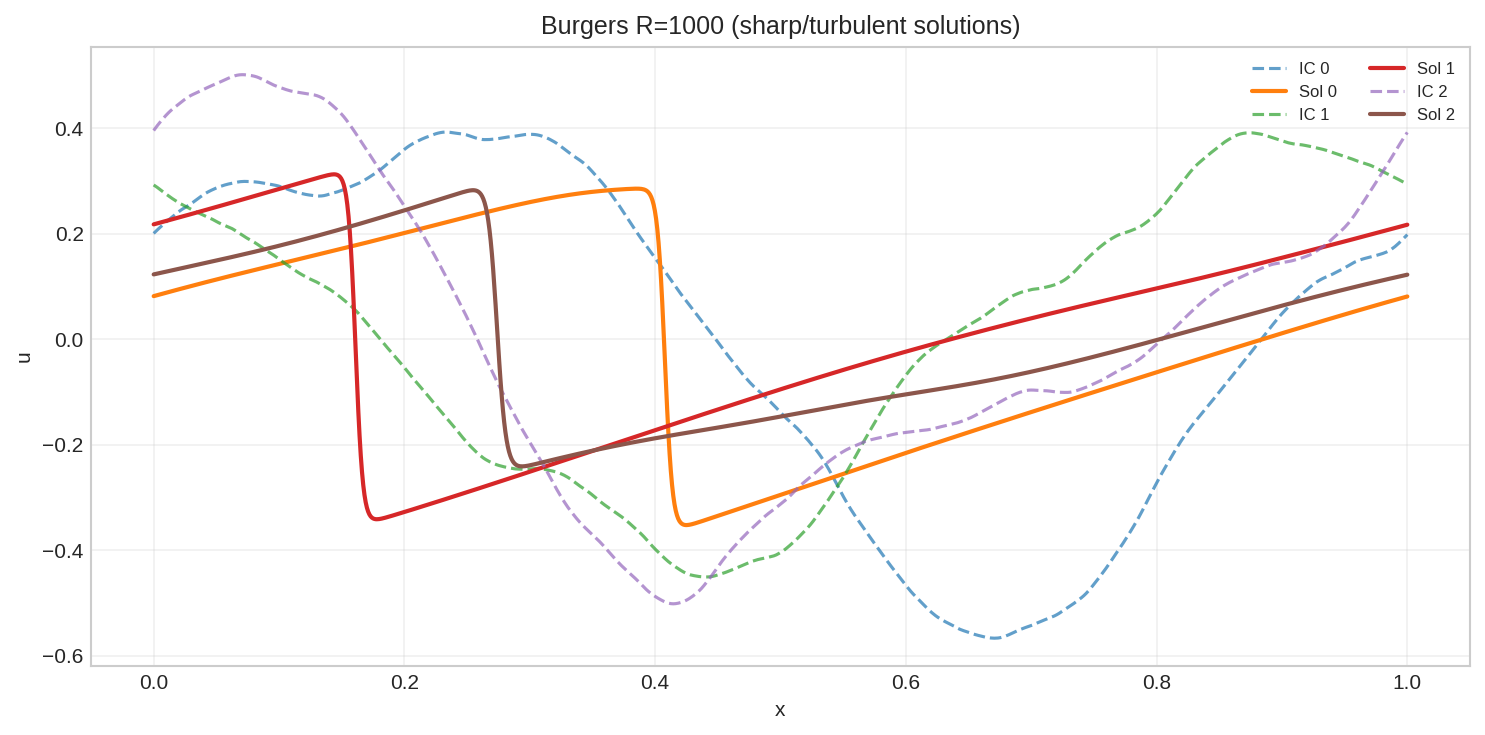

17:02:37 | INFO | Data verification complete.
INFO:DELFNO:Data verification complete.
17:02:37 | INFO | Note: R=1000 has sharper discontinuities than R=10
INFO:DELFNO:Note: R=1000 has sharper discontinuities than R=10


In [ ]:
# @title Cell 10: Load and Verify Data
log.info("Loading and verifying dataset...")

data_r1000 = load_burgers_data(cfg)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
x = np.linspace(0, 1, cfg.resolution)

for i in range(3):
    ax.plot(x, data_r1000['a'][i].cpu(), '--', label=f'IC {i}', alpha=0.7)
    ax.plot(x, data_r1000['u'][i].cpu(), '-', label=f'Sol {i}', linewidth=2)

ax.set_xlabel('x')
ax.set_ylabel('u')
ax.set_title(f'Burgers R={cfg.reynolds} (sharp/turbulent solutions)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{cfg.results_dir}/data_verification_{cfg.dataset}.png", dpi=150, bbox_inches='tight')
plt.show()

log.info("Data verification complete.")
log.info(f"Note: R=1000 has sharper discontinuities than R=10")

In [ ]:
# @title Cell 11: Experiment 1 - Noise Robustness
log.info("="*60)
log.info("EXPERIMENT 1: NOISE ROBUSTNESS")
log.info("="*60)

df_noise = run_experiment_grid(
    experiment_name='exp1_noise_robustness',
    variable_name='noise_level',
    variable_values=cfg.noise_levels,
    cfg=cfg,
    fixed_params={'n_train': cfg.n_train, 'modes': cfg.modes}
)

log.info(f"Experiment 1 complete! Shape: {df_noise.shape}")

17:02:37 | INFO | ============================================================
INFO:DELFNO:============================================================
17:02:37 | INFO | EXPERIMENT 1: NOISE ROBUSTNESS
INFO:DELFNO:EXPERIMENT 1: NOISE ROBUSTNESS
17:02:37 | INFO | ============================================================
INFO:DELFNO:============================================================
17:02:37 | INFO | Loading r1000 data...
INFO:DELFNO:Loading r1000 data...
17:02:37 | INFO | Loading: ./data/burgers_v1000_t200_r1024_N2048.mat (3174.1MB)
INFO:DELFNO:Loading: ./data/burgers_v1000_t200_r1024_N2048.mat (3174.1MB)
17:02:37 | INFO |   scipy failed: Please use HDF reader for matlab v7.3 files, e.g. h5py, trying h5py...
INFO:DELFNO:  scipy failed: Please use HDF reader for matlab v7.3 files, e.g. h5py, trying h5py...
17:02:37 | INFO |   h5py keys: ['#refs#', '#subsystem#', 'N', 'gamma', 'input', 'j', 'k', 'output', 's', 'sigma', 'steps', 'tau', 'tspan', 'u', 'u0', 'u0eval', 'visc', 'x']

exp1_noise_robustness:   0%|          | 0/30 [00:00<?, ?it/s]

17:03:15 | INFO | Running: FNO, noise_level=0.0, seed=42
INFO:DELFNO:Running: FNO, noise_level=0.0, seed=42
17:05:02 | INFO | Epoch  100/500: loss=0.042692
INFO:DELFNO:Epoch  100/500: loss=0.042692
17:06:44 | INFO | Epoch  200/500: loss=0.032058
INFO:DELFNO:Epoch  200/500: loss=0.032058
17:08:25 | INFO | Epoch  300/500: loss=0.010273
INFO:DELFNO:Epoch  300/500: loss=0.010273
17:10:08 | INFO | Epoch  400/500: loss=0.003678
INFO:DELFNO:Epoch  400/500: loss=0.003678
17:11:50 | INFO | Epoch  500/500: loss=0.001499
INFO:DELFNO:Epoch  500/500: loss=0.001499
17:11:50 | INFO |   Result: test_err=0.011219, train_err=0.001510, time=510.1s
INFO:DELFNO:  Result: test_err=0.011219, train_err=0.001510, time=510.1s
17:11:50 | INFO | Running: FNO, noise_level=0.0, seed=108
INFO:DELFNO:Running: FNO, noise_level=0.0, seed=108
17:13:31 | INFO | Epoch  100/500: loss=0.042896
INFO:DELFNO:Epoch  100/500: loss=0.042896
17:15:13 | INFO | Epoch  200/500: loss=0.023997
INFO:DELFNO:Epoch  200/500: loss=0.023997


In [ ]:
# @title Cell 12: Experiment 2 - Sample Efficiency
log.info("="*60)
log.info("EXPERIMENT 2: SAMPLE EFFICIENCY")
log.info("="*60)

df_sample = run_experiment_grid(
    experiment_name='exp2_sample_efficiency',
    variable_name='n_train',
    variable_values=cfg.sample_sizes,
    cfg=cfg,
    fixed_params={'noise_level': 0.0, 'modes': cfg.modes}
)

log.info(f"Experiment 2 complete! Shape: {df_sample.shape}")

22:28:49 | INFO | ============================================================
INFO:DELFNO:============================================================
22:28:49 | INFO | EXPERIMENT 2: SAMPLE EFFICIENCY
INFO:DELFNO:EXPERIMENT 2: SAMPLE EFFICIENCY
22:28:49 | INFO | ============================================================
INFO:DELFNO:============================================================
22:28:49 | INFO | Loading r1000 data...
INFO:DELFNO:Loading r1000 data...
22:28:49 | INFO | Loading: ./data/burgers_v1000_t200_r1024_N2048.mat (3174.1MB)
INFO:DELFNO:Loading: ./data/burgers_v1000_t200_r1024_N2048.mat (3174.1MB)
22:28:49 | INFO |   scipy failed: Please use HDF reader for matlab v7.3 files, e.g. h5py, trying h5py...
INFO:DELFNO:  scipy failed: Please use HDF reader for matlab v7.3 files, e.g. h5py, trying h5py...
22:28:49 | INFO |   h5py keys: ['#refs#', '#subsystem#', 'N', 'gamma', 'input', 'j', 'k', 'output', 's', 'sigma', 'steps', 'tau', 'tspan', 'u', 'u0', 'u0eval', 'visc', 'x

exp2_sample_efficiency:   0%|          | 0/30 [00:00<?, ?it/s]

22:29:26 | INFO | Running: FNO, n_train=125, seed=42
INFO:DELFNO:Running: FNO, n_train=125, seed=42
22:29:38 | INFO | Epoch  100/500: loss=0.046959
INFO:DELFNO:Epoch  100/500: loss=0.046959
22:29:50 | INFO | Epoch  200/500: loss=0.028665
INFO:DELFNO:Epoch  200/500: loss=0.028665
22:30:03 | INFO | Epoch  300/500: loss=0.029069
INFO:DELFNO:Epoch  300/500: loss=0.029069
22:30:15 | INFO | Epoch  400/500: loss=0.004637
INFO:DELFNO:Epoch  400/500: loss=0.004637
22:30:27 | INFO | Epoch  500/500: loss=0.002781
INFO:DELFNO:Epoch  500/500: loss=0.002781
22:30:27 | INFO |   Result: test_err=0.106445, train_err=0.002840, time=60.7s
INFO:DELFNO:  Result: test_err=0.106445, train_err=0.002840, time=60.7s
22:30:27 | INFO | Running: FNO, n_train=125, seed=108
INFO:DELFNO:Running: FNO, n_train=125, seed=108
22:30:39 | INFO | Epoch  100/500: loss=0.071479
INFO:DELFNO:Epoch  100/500: loss=0.071479
22:30:51 | INFO | Epoch  200/500: loss=0.038983
INFO:DELFNO:Epoch  200/500: loss=0.038983
22:31:03 | INFO | 

In [ ]:
# @title Cell 13: Experiment 3 - Modes Scaling
log.info("="*60)
log.info("EXPERIMENT 3: MODES SCALING")
log.info("="*60)

df_modes = run_experiment_grid(
    experiment_name='exp3_modes_scaling',
    variable_name='modes',
    variable_values=cfg.modes_list,
    cfg=cfg,
    fixed_params={'n_train': cfg.n_train, 'noise_level': 0.0}
)

log.info(f"Experiment 3 complete! Shape: {df_modes.shape}")

02:27:31 | INFO | ============================================================
INFO:DELFNO:============================================================
02:27:31 | INFO | EXPERIMENT 3: MODES SCALING
INFO:DELFNO:EXPERIMENT 3: MODES SCALING
02:27:31 | INFO | ============================================================
INFO:DELFNO:============================================================
02:27:31 | INFO | Loading r1000 data...
INFO:DELFNO:Loading r1000 data...
02:27:31 | INFO | Loading: ./data/burgers_v1000_t200_r1024_N2048.mat (3174.1MB)
INFO:DELFNO:Loading: ./data/burgers_v1000_t200_r1024_N2048.mat (3174.1MB)
02:27:31 | INFO |   scipy failed: Please use HDF reader for matlab v7.3 files, e.g. h5py, trying h5py...
INFO:DELFNO:  scipy failed: Please use HDF reader for matlab v7.3 files, e.g. h5py, trying h5py...
02:27:31 | INFO |   h5py keys: ['#refs#', '#subsystem#', 'N', 'gamma', 'input', 'j', 'k', 'output', 's', 'sigma', 'steps', 'tau', 'tspan', 'u', 'u0', 'u0eval', 'visc', 'x']
INFO:

exp3_modes_scaling:   0%|          | 0/24 [00:00<?, ?it/s]

02:28:09 | INFO | Running: FNO, modes=16, seed=42
INFO:DELFNO:Running: FNO, modes=16, seed=42
02:29:50 | INFO | Epoch  100/500: loss=0.042692
INFO:DELFNO:Epoch  100/500: loss=0.042692
02:31:32 | INFO | Epoch  200/500: loss=0.032058
INFO:DELFNO:Epoch  200/500: loss=0.032058
02:33:13 | INFO | Epoch  300/500: loss=0.010273
INFO:DELFNO:Epoch  300/500: loss=0.010273
02:34:54 | INFO | Epoch  400/500: loss=0.003678
INFO:DELFNO:Epoch  400/500: loss=0.003678
02:36:35 | INFO | Epoch  500/500: loss=0.001499
INFO:DELFNO:Epoch  500/500: loss=0.001499
02:36:35 | INFO |   Result: test_err=0.011219, train_err=0.001510, time=506.0s
INFO:DELFNO:  Result: test_err=0.011219, train_err=0.001510, time=506.0s
02:36:35 | INFO | Running: FNO, modes=16, seed=108
INFO:DELFNO:Running: FNO, modes=16, seed=108
02:38:16 | INFO | Epoch  100/500: loss=0.042896
INFO:DELFNO:Epoch  100/500: loss=0.042896
02:39:57 | INFO | Epoch  200/500: loss=0.023997
INFO:DELFNO:Epoch  200/500: loss=0.023997
02:41:39 | INFO | Epoch  300

In [ ]:
# @title Cell 14: Analysis Functions
# ═══════════════════════════════════════════════════════════════════
#                    ANALYSIS AND VISUALIZATION
# ═══════════════════════════════════════════════════════════════════

def analyze_results(df: pd.DataFrame, var_col: str, var_values: List,
                    cfg: Config, exp_name: str, xlabel: str):
    """Analyze and plot experiment results."""

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    summary = df.groupby([var_col, 'model'])['test_error'].agg(['mean', 'std']).reset_index()

    # Plot 1: Error vs variable
    ax = axes[0]
    for model in cfg.models:
        data = summary[summary['model'] == model]
        ax.errorbar(data[var_col], data['mean'], yerr=data['std'],
                   marker='o', capsize=4, label=model, linewidth=2, markersize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Relative L2 Error')
    ax.set_title(f'Burgers {cfg.dataset.upper()}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    if var_col in ['n_train', 'modes']:
        ax.set_xscale('log', base=2)

    # Plot 2: Improvement %
    ax = axes[1]
    fno_errors = summary[summary['model'] == 'FNO'].set_index(var_col)['mean']
    del_errors = summary[summary['model'] == 'DEL-FNO'].set_index(var_col)['mean']
    improvement = (fno_errors - del_errors) / fno_errors * 100

    colors = ['green' if x > 0 else 'red' for x in improvement.values]
    ax.bar(range(len(improvement)), improvement.values, color=colors, alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(improvement)))
    ax.set_xticklabels([str(x) for x in improvement.index])
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Improvement (%)')
    ax.set_title(f'{cfg.dataset.upper()}: DEL-FNO Improvement')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='y')

    # Plot 3: Learned β values
    ax = axes[2]
    df_del = df[df['model'] == 'DEL-FNO']
    for i in range(cfg.nb_beta):
        beta_by_var = df_del.groupby(var_col).apply(
            lambda x: np.mean([b[i] for b in x['beta_values'] if b is not None])
        )
        marker = 'o' if i == 0 else 's'
        ax.plot(beta_by_var.index, beta_by_var.values, f'{marker}-',
               label=f'β{i+1}', markersize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Learned β')
    ax.set_title('Learned Derivative Orders')
    ax.legend()
    ax.grid(True, alpha=0.3)
    if var_col in ['n_train', 'modes']:
        ax.set_xscale('log', base=2)

    plt.suptitle(f'{exp_name} - {cfg.dataset.upper()}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{cfg.results_dir}/{exp_name.lower().replace(' ', '_')}_{cfg.dataset}.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    # Print summary table
    log.info(f"\n{exp_name} Summary:")
    log.info("-" * 70)
    log.info(f"{'Value':<12} {'FNO Error':<15} {'DEL-FNO Error':<15} {'Improvement':<12}")
    log.info("-" * 70)
    for val in var_values:
        df_v = df[df[var_col] == val]
        fno_err = df_v[df_v['model'] == 'FNO']['test_error'].mean()
        del_err = df_v[df_v['model'] == 'DEL-FNO']['test_error'].mean()
        imp = (fno_err - del_err) / fno_err * 100
        log.info(f"{str(val):<12} {fno_err:<15.6f} {del_err:<15.6f} {imp:+.1f}%")
    log.info("-" * 70)

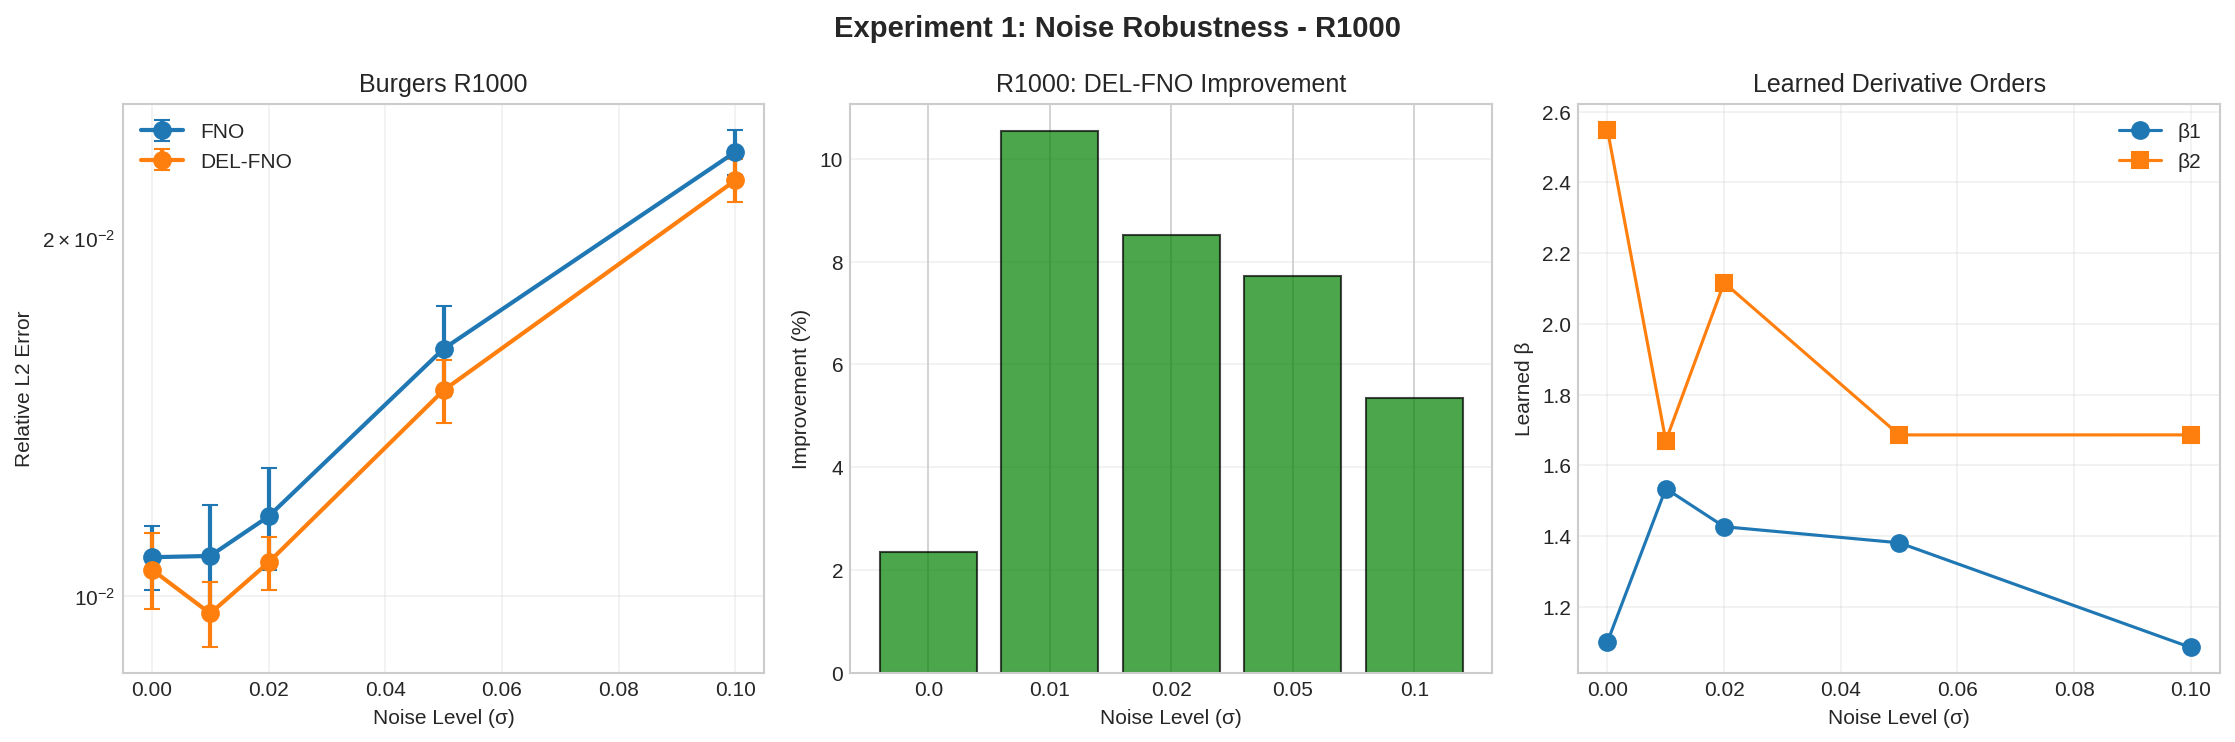

07:05:24 | INFO | 
Experiment 1: Noise Robustness Summary:
INFO:DELFNO:
Experiment 1: Noise Robustness Summary:
07:05:24 | INFO | ----------------------------------------------------------------------
INFO:DELFNO:----------------------------------------------------------------------
07:05:24 | INFO | Value        FNO Error       DEL-FNO Error   Improvement 
INFO:DELFNO:Value        FNO Error       DEL-FNO Error   Improvement 
07:05:24 | INFO | ----------------------------------------------------------------------
INFO:DELFNO:----------------------------------------------------------------------
07:05:24 | INFO | 0.0          0.010789        0.010535        +2.4%
INFO:DELFNO:0.0          0.010789        0.010535        +2.4%
07:05:24 | INFO | 0.01         0.010816        0.009677        +10.5%
INFO:DELFNO:0.01         0.010816        0.009677        +10.5%
07:05:24 | INFO | 0.02         0.011675        0.010681        +8.5%
INFO:DELFNO:0.02         0.011675        0.010681        +8.5%


In [ ]:
# Cell 15: Analyze Noise Results
analyze_results(df_noise, 'noise_level', cfg.noise_levels, cfg,
                'Experiment 1: Noise Robustness', 'Noise Level (σ)')

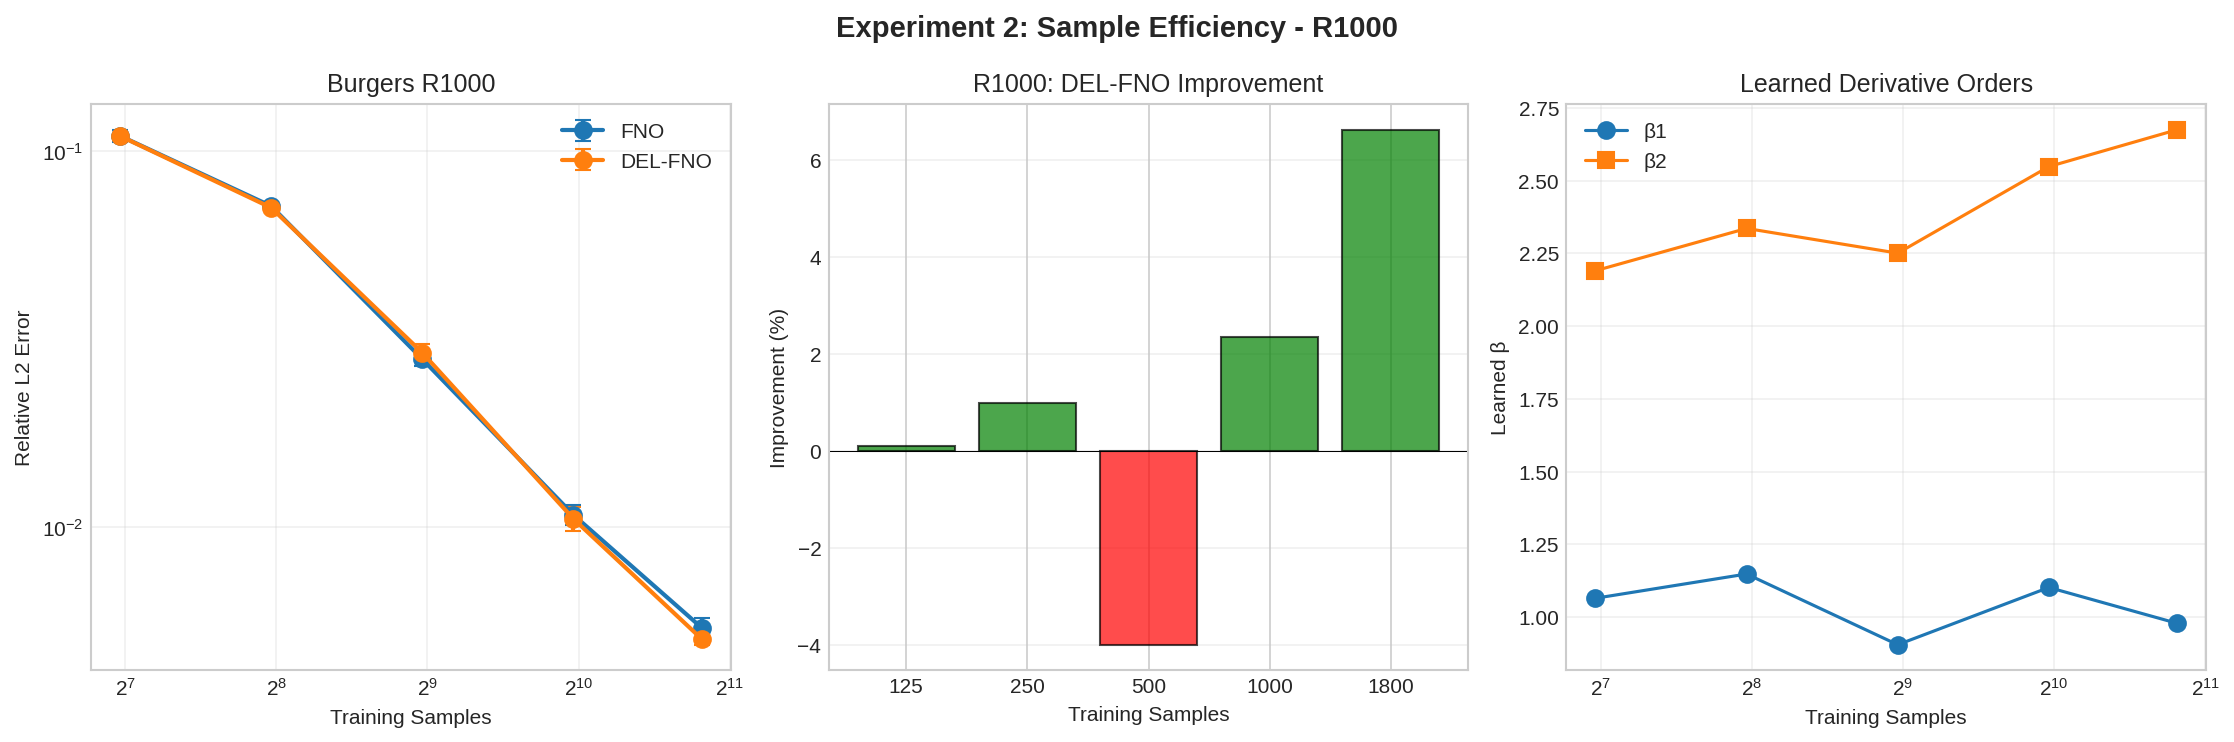

07:05:25 | INFO | 
Experiment 2: Sample Efficiency Summary:
INFO:DELFNO:
Experiment 2: Sample Efficiency Summary:
07:05:25 | INFO | ----------------------------------------------------------------------
INFO:DELFNO:----------------------------------------------------------------------
07:05:25 | INFO | Value        FNO Error       DEL-FNO Error   Improvement 
INFO:DELFNO:Value        FNO Error       DEL-FNO Error   Improvement 
07:05:25 | INFO | ----------------------------------------------------------------------
INFO:DELFNO:----------------------------------------------------------------------
07:05:25 | INFO | 125          0.109973        0.109859        +0.1%
INFO:DELFNO:125          0.109973        0.109859        +0.1%
07:05:25 | INFO | 250          0.071528        0.070818        +1.0%
INFO:DELFNO:250          0.071528        0.070818        +1.0%
07:05:25 | INFO | 500          0.028015        0.029134        -4.0%
INFO:DELFNO:500          0.028015        0.029134        -4.0%


In [ ]:
# @title Cell 16: Analyze Sample Efficiency Results
analyze_results(df_sample, 'n_train', cfg.sample_sizes, cfg,
                'Experiment 2: Sample Efficiency', 'Training Samples')

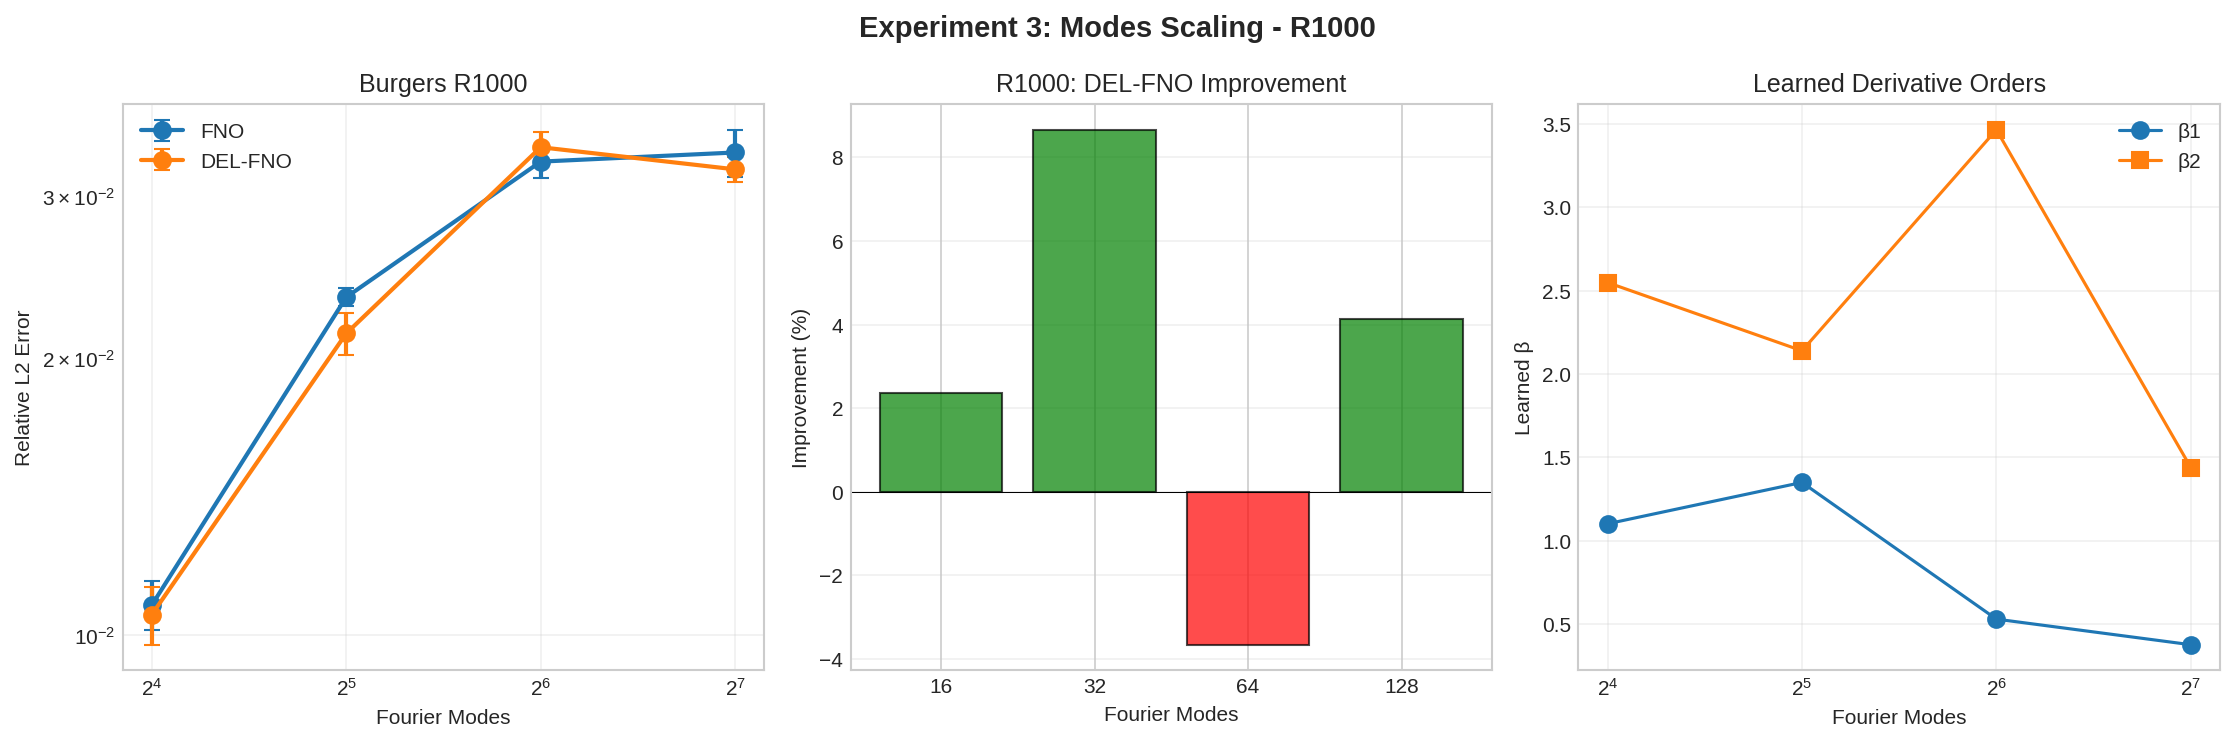

07:05:26 | INFO | 
Experiment 3: Modes Scaling Summary:
INFO:DELFNO:
Experiment 3: Modes Scaling Summary:
07:05:26 | INFO | ----------------------------------------------------------------------
INFO:DELFNO:----------------------------------------------------------------------
07:05:26 | INFO | Value        FNO Error       DEL-FNO Error   Improvement 
INFO:DELFNO:Value        FNO Error       DEL-FNO Error   Improvement 
07:05:26 | INFO | ----------------------------------------------------------------------
INFO:DELFNO:----------------------------------------------------------------------
07:05:26 | INFO | 16           0.010789        0.010535        +2.4%
INFO:DELFNO:16           0.010789        0.010535        +2.4%
07:05:26 | INFO | 32           0.023300        0.021282        +8.7%
INFO:DELFNO:32           0.023300        0.021282        +8.7%
07:05:26 | INFO | 64           0.032705        0.033904        -3.7%
INFO:DELFNO:64           0.032705        0.033904        -3.7%
07:05:26

In [ ]:
# @title Cell 17: Analyze Modes Results
analyze_results(df_modes, 'modes', cfg.modes_list, cfg,
                'Experiment 3: Modes Scaling', 'Fourier Modes')

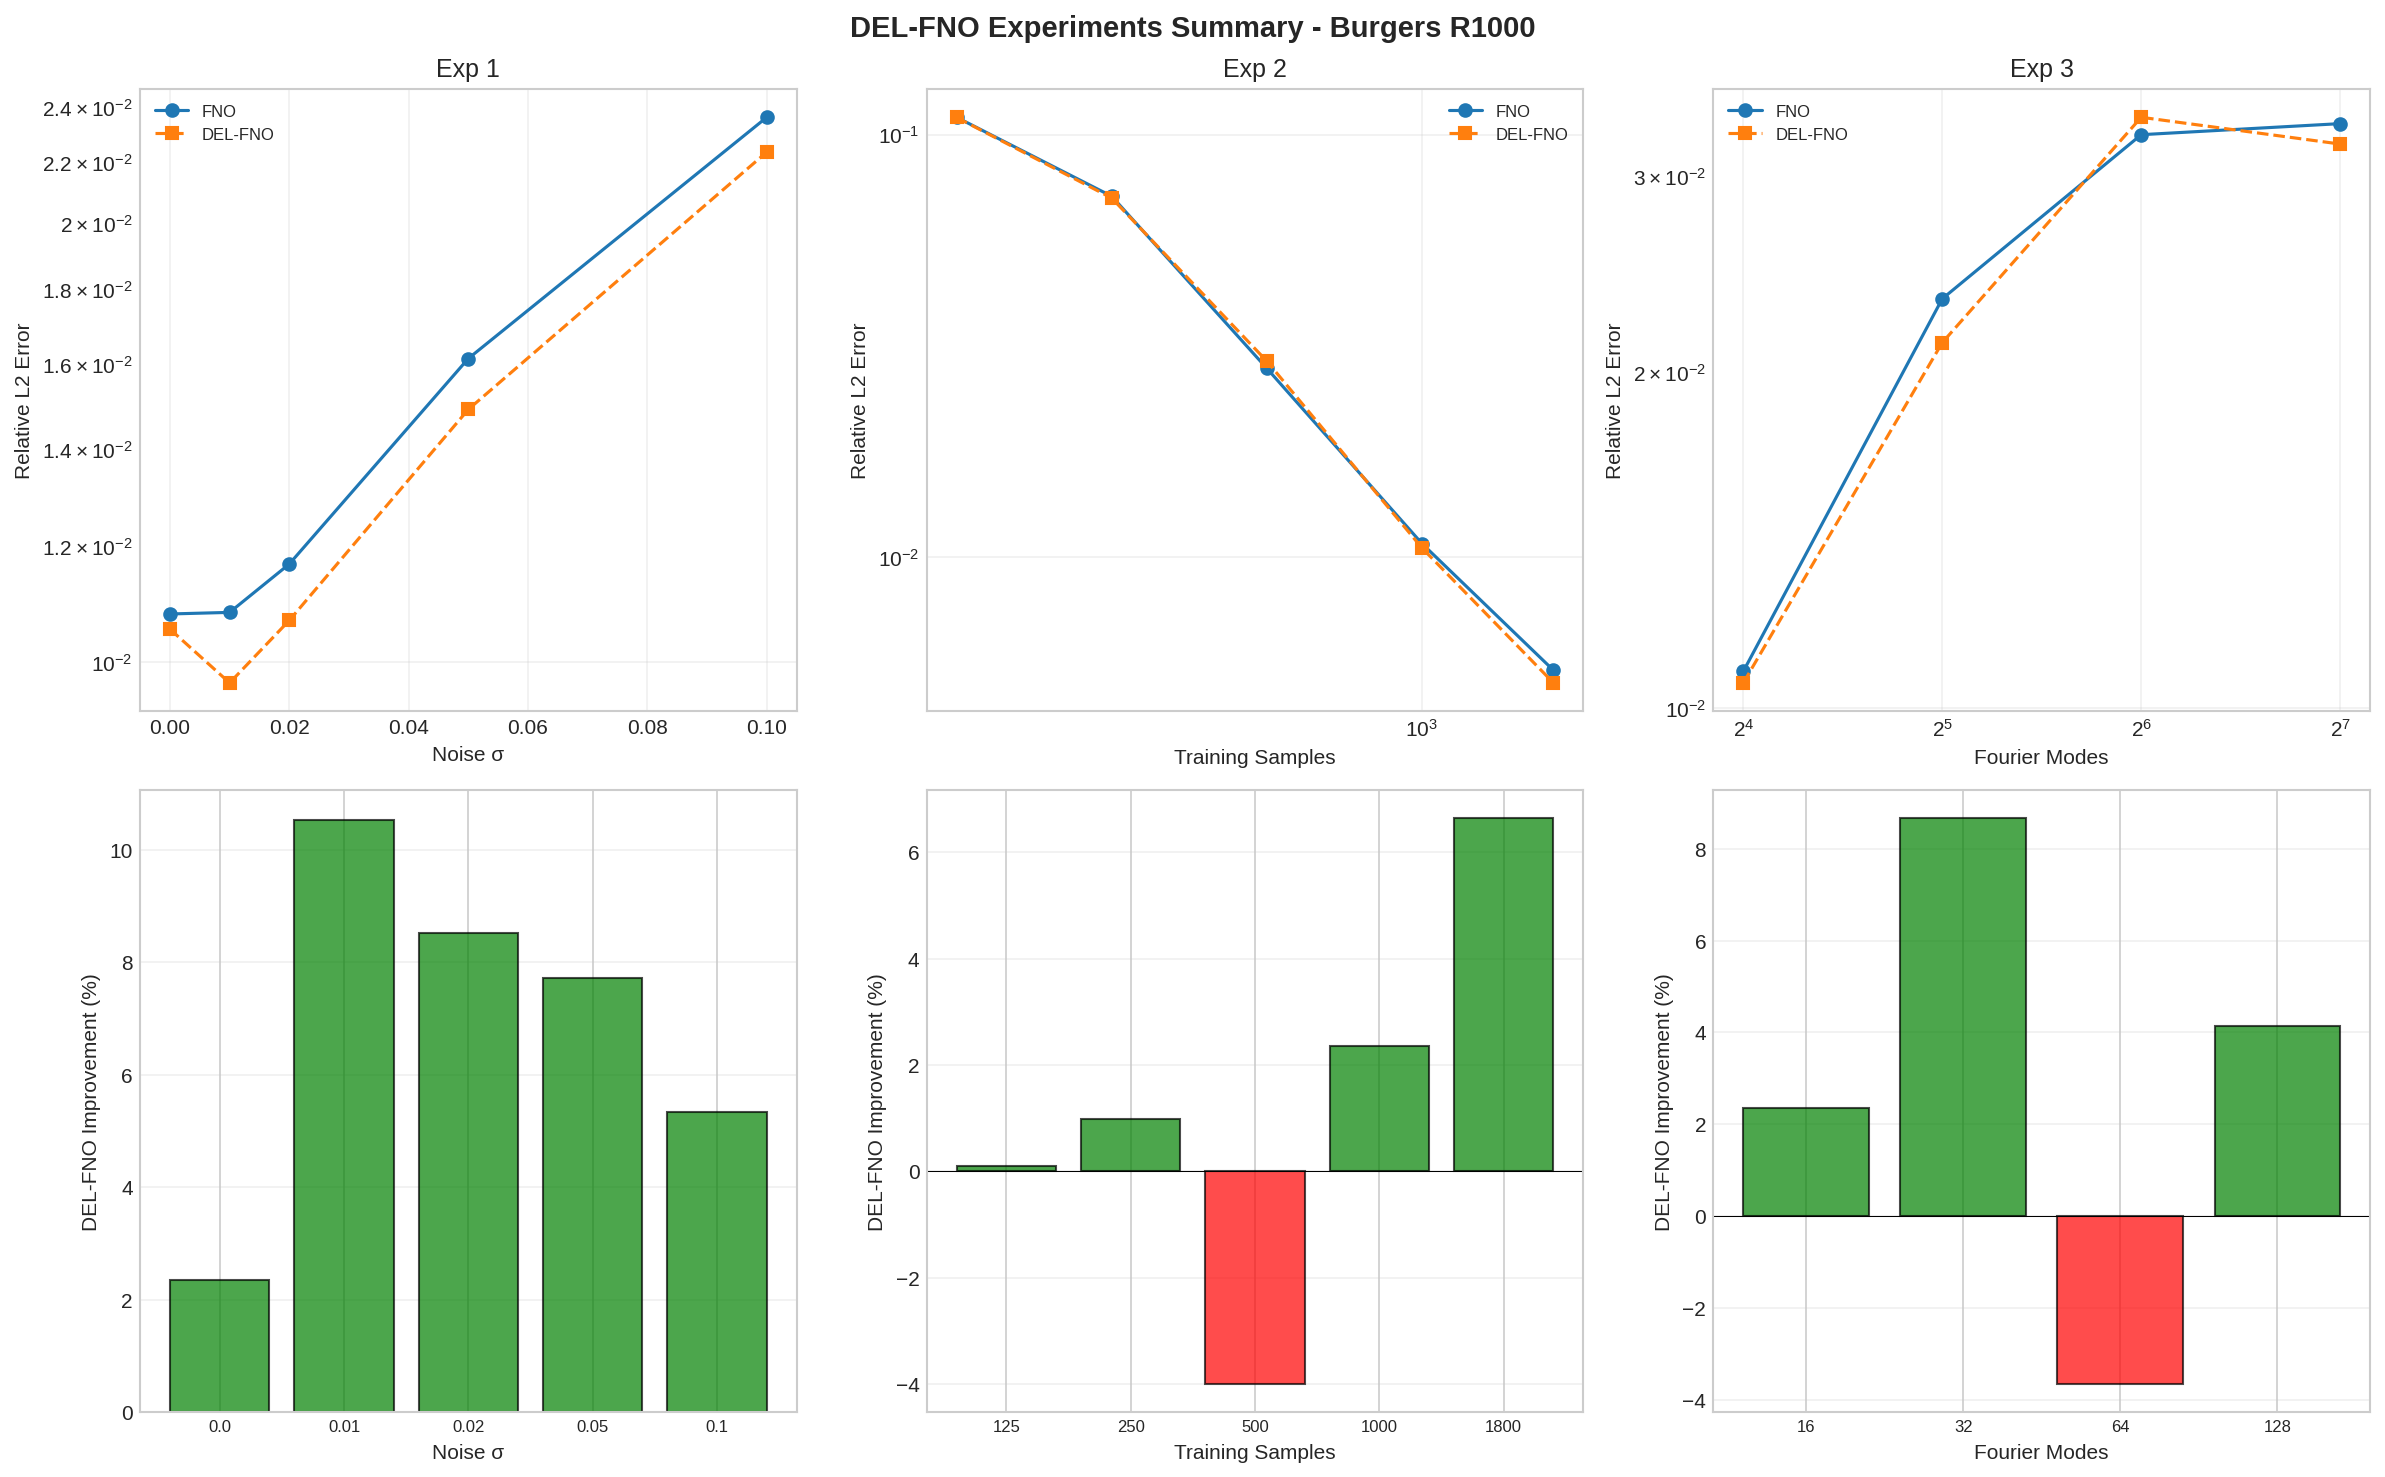

In [ ]:
# @title Cell 18: Summary Figure
def create_summary_figure(cfg: Config):
    """Create comprehensive summary of all experiments."""

    df_noise = pd.read_csv(f"{cfg.results_dir}/exp1_noise_robustness_{cfg.dataset}.csv")
    df_sample = pd.read_csv(f"{cfg.results_dir}/exp2_sample_efficiency_{cfg.dataset}.csv")
    df_modes = pd.read_csv(f"{cfg.results_dir}/exp3_modes_scaling_{cfg.dataset}.csv")

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    experiments = [
        (df_noise, 'noise_level', 'Noise σ', cfg.noise_levels, 'linear'),
        (df_sample, 'n_train', 'Training Samples', cfg.sample_sizes, 'log'),
        (df_modes, 'modes', 'Fourier Modes', cfg.modes_list, 'log2'),
    ]

    # Row 1: Error curves
    for col, (df, var_col, xlabel, values, xscale) in enumerate(experiments):
        ax = axes[0, col]
        for model in cfg.models:
            df_m = df[df['model'] == model]
            err = df_m.groupby(var_col)['test_error'].mean()
            style = '-o' if model == 'FNO' else '--s'
            ax.plot(err.index, err.values, style, label=model, markersize=6)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Relative L2 Error')
        ax.set_title(f'Exp {col+1}')
        ax.legend(fontsize=8)
        ax.set_yscale('log')
        if xscale == 'log':
            ax.set_xscale('log')
        elif xscale == 'log2':
            ax.set_xscale('log', base=2)
        ax.grid(True, alpha=0.3)

    # Row 2: Improvement bars
    for col, (df, var_col, xlabel, values, _) in enumerate(experiments):
        ax = axes[1, col]
        imps = []
        for v in values:
            df_v = df[df[var_col] == v]
            fno = df_v[df_v['model'] == 'FNO']['test_error'].mean()
            del_fno = df_v[df_v['model'] == 'DEL-FNO']['test_error'].mean()
            imps.append((fno - del_fno) / fno * 100)

        colors = ['green' if x > 0 else 'red' for x in imps]
        ax.bar(range(len(values)), imps, color=colors, alpha=0.7, edgecolor='black')
        ax.set_xticks(range(len(values)))
        ax.set_xticklabels([str(v) for v in values], fontsize=8)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('DEL-FNO Improvement (%)')
        ax.axhline(y=0, color='black', linewidth=0.5)
        ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle(f'DEL-FNO Experiments Summary - Burgers {cfg.dataset.upper()}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{cfg.results_dir}/summary_all_experiments_{cfg.dataset}.png",
                dpi=200, bbox_inches='tight')
    plt.show()

create_summary_figure(cfg)